# 05 Clustering

This notebook applies unsupervised clustering to identify distinct market regimes in the crypto market. The idea builds on the EDA findings: BTC correlations, volatility, and return dispersion all fluctuate over time in ways that suggest the market alternates between different structural states (calm vs. crisis periods).

The approach:
1. Aggregate the per-asset features from notebook `02` into daily cross-sectional summaries that describe the overall market state on each day.
2. Use K-Means clustering to partition trading days into regimes.
3. Evaluate cluster quality with the elbow method and silhouette scores.
4. Characterize the discovered regimes and check whether they align with known market events.

All runs (per value of $k$, plus the final fit) are tracked with **MLflow** under the `clustering` experiment so configurations can be compared in the MLflow UI.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

import mlflow

sys.path.append(str(Path.cwd().resolve().parent))
from mlflow_utils import get_or_create_experiment, EXPERIMENT_CLUSTERING
from src.utils.plot_config import COIN_COLORS, apply_plot_style

apply_plot_style()

get_or_create_experiment(EXPERIMENT_CLUSTERING)
mlflow.set_experiment(EXPERIMENT_CLUSTERING)

## Configuration

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Input paths (outputs of notebook 02)
FEATURES_LONG_ALIGNED_PATH = DATA_PROCESSED_DIR / "crypto_features_long_aligned.csv"
LOG_RETURNS_ALIGNED_PATH = DATA_PROCESSED_DIR / "crypto_wide_log_returns_aligned.csv"
MACRO_RETURNS_ALIGNED_PATH = DATA_PROCESSED_DIR / "macro_wide_log_returns_aligned.csv"

# Output paths
REGIME_LABELS_OUTPUT_PATH = DATA_PROCESSED_DIR / "regime_labels_baseline.csv"

RANDOM_STATE = 42
K_RANGE = range(2, 7)

## Load data

In [3]:
features_long_df = pd.read_csv(FEATURES_LONG_ALIGNED_PATH, parse_dates=["Date"])
log_returns_df = pd.read_csv(LOG_RETURNS_ALIGNED_PATH, parse_dates=["Date"], index_col="Date")
macro_returns_df = pd.read_csv(MACRO_RETURNS_ALIGNED_PATH, parse_dates=["Date"], index_col="Date")

print("Features long shape:", features_long_df.shape)
print("Log returns shape:", log_returns_df.shape)
print("Macro returns shape:", macro_returns_df.shape)

Features long shape: (13044, 15)
Log returns shape: (2174, 6)
Macro returns shape: (2174, 4)


## Build daily market-state features

The feature table from notebook `02` contains one row per asset per day. For regime clustering, the goal is to describe the overall market state on each day — not individual asset behavior. To do this, the per-asset features are aggregated into daily cross-sectional summaries.

The following daily features are computed:

| Feature | Description |
| --- | --- |
| `mean_log_return` | Average log return across all assets |
| `return_dispersion` | Standard deviation of log returns across assets (measures how differently assets behave on a given day) |
| `mean_volatility` | Average 30-day rolling volatility |
| `mean_btc_corr` | Average 30-day BTC correlation across altcoins (BTC excluded) |
| `mean_idio_vol` | Average idiosyncratic volatility across altcoins (BTC excluded) |
| `dxy_log_return` | DXY daily log return |
| `vix_log_return` | VIX daily log return |
| `gold_log_return` | Gold daily log return |
| `sp500_log_return` | S&P 500 daily log return |

In [ ]:
from src.features.daily import build_daily_market_features

In [5]:
daily_features_df = build_daily_market_features(features_long_df)

print("Daily features shape:", daily_features_df.shape)
print("\nMissing values:")
print(daily_features_df.isna().sum())

Daily features shape: (2174, 9)

Missing values:
mean_log_return       1
return_dispersion     1
mean_volatility      30
mean_btc_corr        30
mean_idio_vol        30
dxy_log_return        4
gold_log_return       4
sp500_log_return      4
vix_log_return        4
dtype: int64


In [6]:
daily_features_clean_df = daily_features_df.dropna().copy()

print("Shape before dropping NaNs:", daily_features_df.shape)
print("Shape after dropping NaNs:", daily_features_clean_df.shape)
print(f"Dropped {len(daily_features_df) - len(daily_features_clean_df)} rows")

daily_features_clean_df.head()

Shape before dropping NaNs: (2174, 9)
Shape after dropping NaNs: (2144, 9)
Dropped 30 rows


,mean_log_return,return_dispersion,mean_volatility,mean_btc_corr,mean_idio_vol,dxy_log_return,gold_log_return,sp500_log_return,vix_log_return
Date,,,,,,,,,
2020-05-10,-0.107129,0.014830,0.047262,0.722147,0.034981,0.000000,0.000000,0.000000,0.000000
2020-05-11,-0.020996,0.010383,0.046322,0.729057,0.033585,0.005101,-0.008575,0.000133,-0.014762
2020-05-12,0.030535,0.012004,0.045797,0.734064,0.032777,-0.003097,0.005353,-0.020713,0.180991
2020-05-13,0.033102,0.014469,0.045399,0.742890,0.031832,0.003097,0.005558,-0.017617,0.065597
2020-05-14,0.023250,0.015059,0.044588,0.746671,0.030742,0.002292,0.014021,0.011459,-0.078697


## Standardize features

K-Means uses Euclidean distance, which means features with larger scales would dominate the clustering. All features are standardized to zero mean and unit variance before fitting.

In [7]:
feature_columns = daily_features_clean_df.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(daily_features_clean_df[feature_columns])

print("Scaled feature matrix shape:", X_scaled.shape)
print("\nFeature means after scaling (should be ~0):")
print(pd.Series(X_scaled.mean(axis=0), index=feature_columns).round(6))

Scaled feature matrix shape: (2144, 9)

Feature means after scaling (should be ~0):
mean_log_return     -0.0
return_dispersion    0.0
mean_volatility     -0.0
mean_btc_corr       -0.0
mean_idio_vol       -0.0
dxy_log_return       0.0
gold_log_return      0.0
sp500_log_return     0.0
vix_log_return      -0.0
dtype: float64


## Selecting the number of clusters

Two standard methods are used to choose a reasonable value of $k$:

- **Elbow method:** Plot the within-cluster sum of squares against $k$. The "elbow" is the point where adding more clusters gives diminishing returns.
- **Silhouette score:** Measures how similar each point is to its own cluster compared to the nearest other cluster. Ranges from $-1$ (wrong cluster) to $+1$ (well matched). Higher average scores indicate better-separated clusters.

In [8]:
inertias = []
silhouette_scores = []

FEATURES_USED = ",".join(feature_columns)

for k in K_RANGE:
    with mlflow.start_run(run_name=f"kmeans_sweep_k={k}"):
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)

        mlflow.log_param("algorithm", "kmeans")
        mlflow.log_param("n_clusters", k)
        mlflow.log_param("random_state", RANDOM_STATE)
        mlflow.log_param("n_init", 10)
        mlflow.log_param("dataset", "aligned_6_assets_from_2020")
        mlflow.log_param("n_features", X_scaled.shape[1])
        mlflow.log_param("features_used", FEATURES_USED)

        mlflow.log_metric("silhouette_score", sil)
        mlflow.log_metric("inertia", kmeans.inertia_)

        inertias.append(kmeans.inertia_)
        silhouette_scores.append(sil)

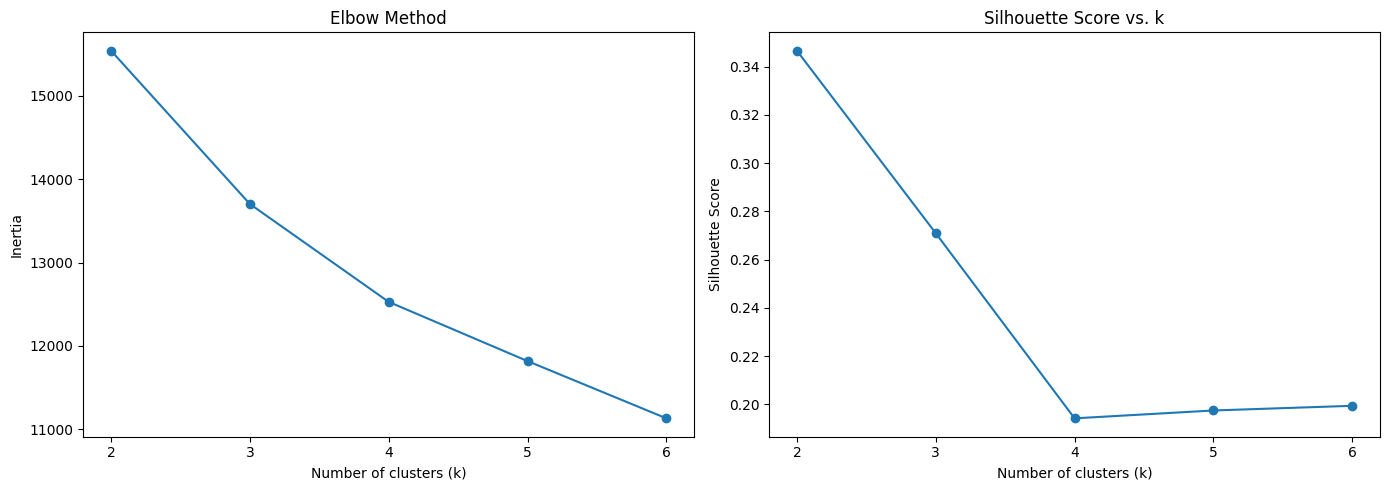


Silhouette scores per k:
  k=2: 0.3466
  k=3: 0.2709
  k=4: 0.1942
  k=5: 0.1975
  k=6: 0.1994


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, "o-")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(list(K_RANGE), silhouette_scores, "o-")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

print("\nSilhouette scores per k:")
for k, s in zip(K_RANGE, silhouette_scores):
    print(f"  k={k}: {s:.4f}")

## Fit baseline model

Based on the elbow and silhouette plots above, a value of $k$ is chosen for the baseline. For regime detection in financial markets, 3–4 clusters typically correspond to interpretable states (e.g., calm, trending, crisis).

In [10]:
# K=2 chosen to match the HMM regime detection in notebook 06 for a fair side-by-side comparison
# (same K isolates the model-type effect rather than mixing it with a granularity difference).
BASELINE_K = 2

with mlflow.start_run(run_name=f"kmeans_final_k={BASELINE_K}") as final_run:
    kmeans_baseline = KMeans(n_clusters=BASELINE_K, random_state=RANDOM_STATE, n_init=10)
    cluster_labels = kmeans_baseline.fit_predict(X_scaled)

    daily_features_clean_df["regime"] = cluster_labels

    sil = silhouette_score(X_scaled, cluster_labels)

    mlflow.log_param("algorithm", "kmeans")
    mlflow.log_param("n_clusters", BASELINE_K)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("n_init", 10)
    mlflow.log_param("dataset", "aligned_6_assets_from_2020")
    mlflow.log_param("features_used", FEATURES_USED)
    mlflow.set_tag("stage", "final")

    mlflow.log_metric("silhouette_score", sil)
    mlflow.log_metric("inertia", kmeans_baseline.inertia_)
    for regime_id, size in pd.Series(cluster_labels).value_counts().sort_index().items():
        mlflow.log_metric(f"cluster_{regime_id}_size", int(size))

print(f"Final K-Means with k={BASELINE_K}")
print(f"Silhouette score: {sil:.4f}")
print(f"Inertia: {kmeans_baseline.inertia_:.2f}")
print(f"\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())
print(f"\nMLflow run_id: {final_run.info.run_id}")

Final K-Means with k=2
Silhouette score: 0.3466
Inertia: 15540.13

Cluster sizes:
0     369
1    1775
Name: count, dtype: int64

MLflow run_id: 99119d6ab5e4437c9cc0f7e3d3255797


## Visualize clusters in PCA space

The feature space has 9 dimensions, so PCA is used to project the data down to 2 dimensions for visualization. This is only for plotting so the clustering itself uses the full feature space.

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Explained variance by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total explained variance (2 components): {pca.explained_variance_ratio_.sum():.2%}")

Explained variance by PC1: 26.96%
Explained variance by PC2: 23.31%
Total explained variance (2 components): 50.27%


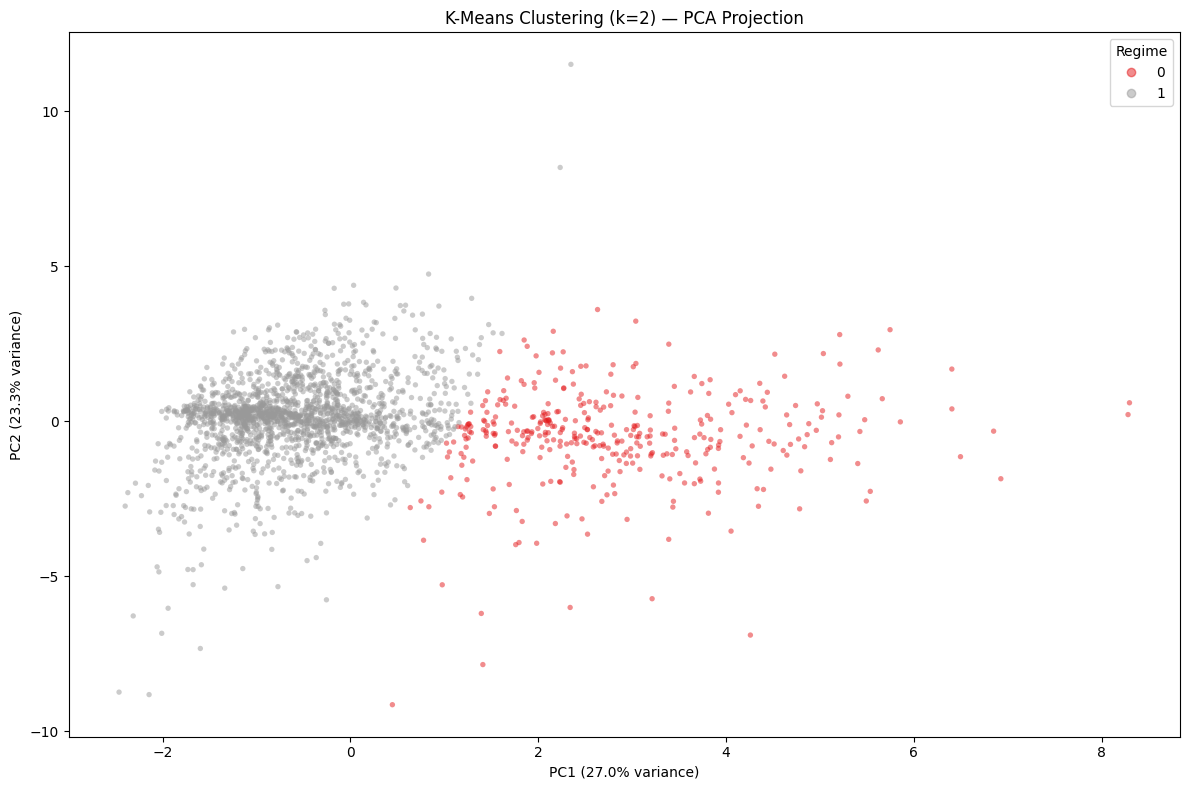

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_labels, cmap="Set1", alpha=0.5, s=15, edgecolors="none",
)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title(f"K-Means Clustering (k={BASELINE_K}) PCA Projection")
ax.legend(*scatter.legend_elements(), title="Regime")

plt.tight_layout()
plt.show()

## Regime timeline

Plotting the regime labels over time shows when the market transitions between states. If the clustering is meaningful, the regimes should correspond to recognizable market periods.

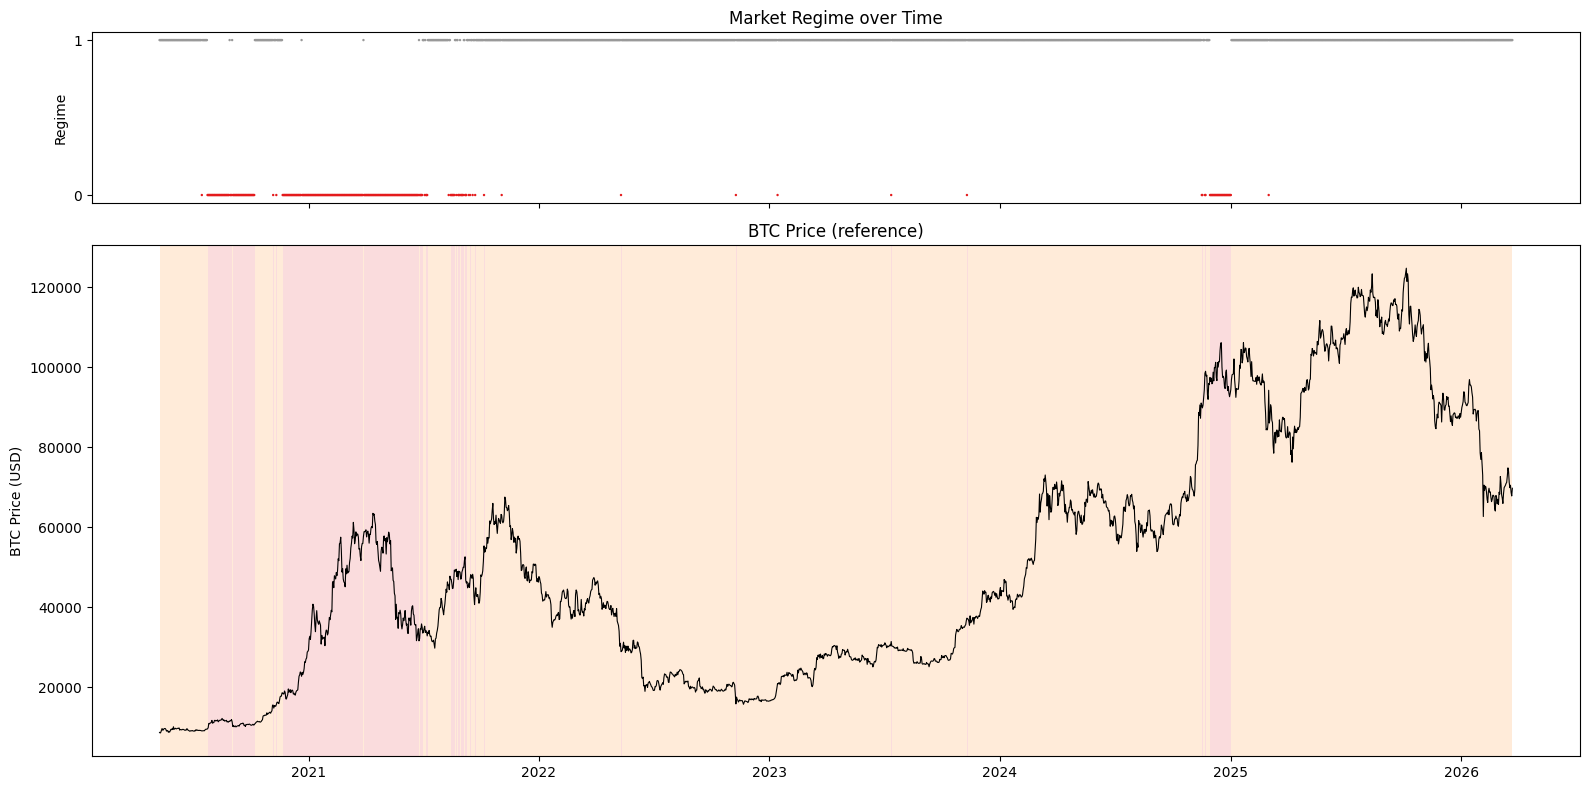

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True, gridspec_kw={"height_ratios": [1, 3]})

# Top panel: regime labels over time
dates = daily_features_clean_df.index
axes[0].scatter(dates, cluster_labels, c=cluster_labels, cmap="Set1", s=3, edgecolors="none")
axes[0].set_ylabel("Regime")
axes[0].set_yticks(range(BASELINE_K))
axes[0].set_title("Market Regime over Time")

# Bottom panel: BTC price for reference
btc_close = pd.read_csv(
    DATA_PROCESSED_DIR / "crypto_wide_close_aligned.csv",
    parse_dates=["Date"], index_col="Date",
)["BTC"]

btc_close_filtered = btc_close.loc[dates[0]:dates[-1]]
axes[1].plot(btc_close_filtered.index, btc_close_filtered.values, color="black", linewidth=0.8)
axes[1].set_ylabel("BTC Price (USD)")
axes[1].set_title("BTC Price (reference)")

# Shade background by regime
for i in range(len(dates) - 1):
    color = plt.cm.Set1(cluster_labels[i] / BASELINE_K)
    axes[1].axvspan(dates[i], dates[i + 1], alpha=0.15, color=color, linewidth=0)

plt.tight_layout()
plt.show()

## Regime characterization

To understand what each cluster represents, the average feature values per regime are compared. This reveals the dominant characteristics of each market state.

In [14]:
regime_summary = daily_features_clean_df.groupby("regime")[feature_columns].mean()
regime_summary

,mean_log_return,return_dispersion,mean_volatility,mean_btc_corr,mean_idio_vol,dxy_log_return,gold_log_return,sp500_log_return,vix_log_return
regime,,,,,,,,,
0,0.007724,0.048437,0.065852,0.534356,0.056805,0.000063,-0.000002,0.000625,-0.001486
1,0.000059,0.018683,0.034299,0.709274,0.022924,-0.000014,0.000532,0.000319,0.000274


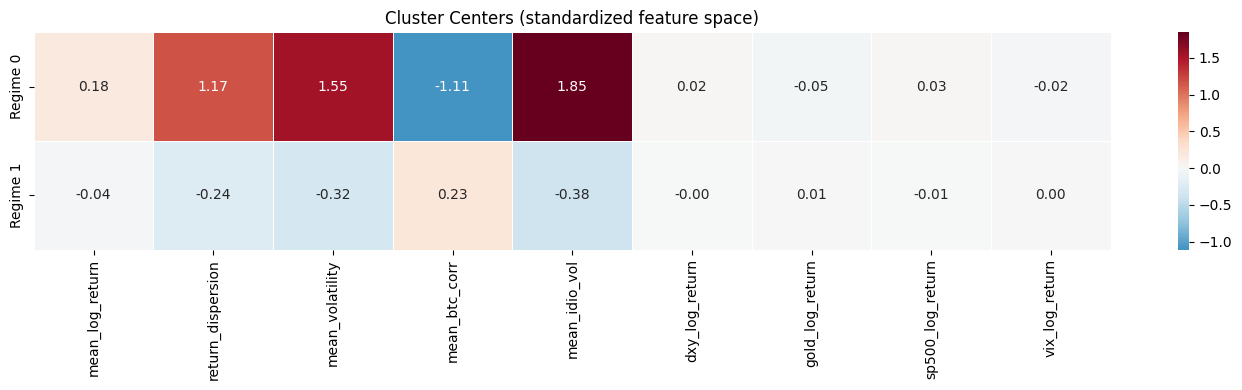

In [15]:
# Heatmap of standardized cluster centers for easier comparison
centers_scaled = pd.DataFrame(
    kmeans_baseline.cluster_centers_,
    columns=feature_columns,
    index=[f"Regime {i}" for i in range(BASELINE_K)],
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(centers_scaled, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, linewidths=0.5)
ax.set_title("Cluster Centers (standardized feature space)")
plt.tight_layout()
plt.show()

### Feature distributions by regime

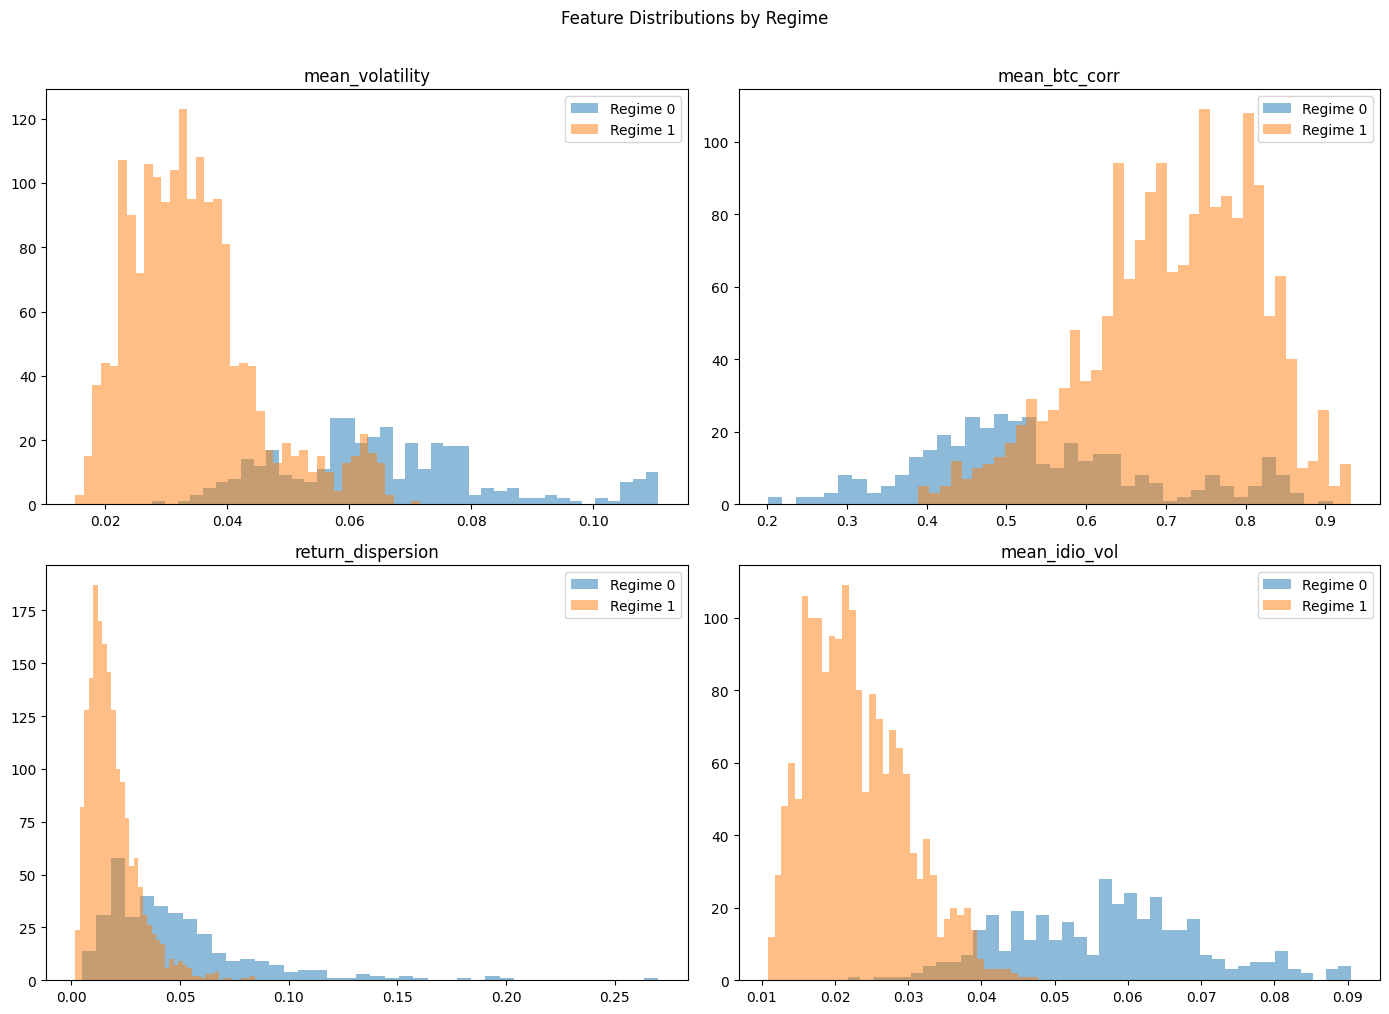

In [16]:
key_features = ["mean_volatility", "mean_btc_corr", "return_dispersion", "mean_idio_vol"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for regime in range(BASELINE_K):
        mask = daily_features_clean_df["regime"] == regime
        axes[i].hist(
            daily_features_clean_df.loc[mask, feat],
            bins=40, alpha=0.5, label=f"Regime {regime}",
        )
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle("Feature Distributions by Regime", y=1.01)
plt.tight_layout()
plt.show()

## Silhouette analysis

A silhouette plot shows how well each individual data point fits its assigned cluster. Points with negative silhouette values are closer to a neighboring cluster than to their own.

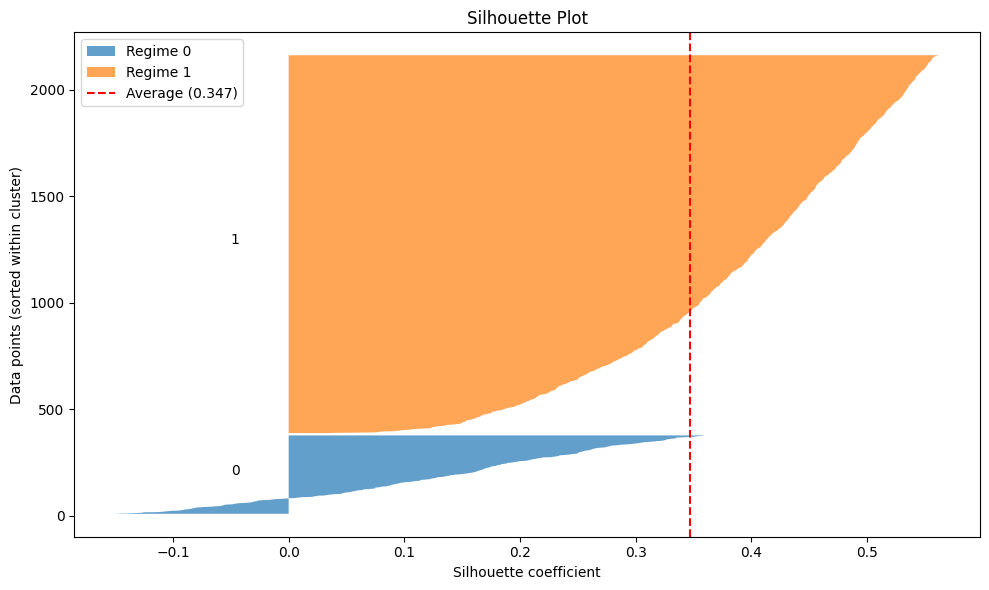

In [17]:
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)
avg_score = silhouette_score(X_scaled, cluster_labels)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in range(BASELINE_K):
    cluster_silhouette = sample_silhouette_values[cluster_labels == i]
    cluster_silhouette.sort()
    cluster_size = len(cluster_silhouette)
    y_upper = y_lower + cluster_size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, cluster_silhouette, alpha=0.7, label=f"Regime {i}",
    )
    ax.text(-0.05, y_lower + 0.5 * cluster_size, str(i))
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color="red", linestyle="--", label=f"Average ({avg_score:.3f})")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Data points (sorted within cluster)")
ax.set_title("Silhouette Plot")
ax.legend()

plt.tight_layout()
plt.show()

## Regime transition frequency

Counting how often the market switches between regimes gives a sense of stability. Frequent switching may indicate that the clustering is too noisy, while rare transitions suggest more persistent regimes.

In [18]:
regime_series = daily_features_clean_df["regime"]
transitions = (regime_series != regime_series.shift(1)).sum() - 1  # subtract first row

total_days = len(regime_series)
print(f"Total trading days: {total_days}")
print(f"Total regime transitions: {transitions}")
print(f"Average regime duration: {total_days / (transitions + 1):.1f} days")

# Transition matrix (row = from, column = to)
transition_pairs = pd.DataFrame({
    "from": regime_series.values[:-1],
    "to": regime_series.values[1:],
})
transition_matrix = pd.crosstab(transition_pairs["from"], transition_pairs["to"], normalize="index")

print("\nTransition probability matrix (row → column):")
transition_matrix

Total trading days: 2144
Total regime transitions: 66
Average regime duration: 32.0 days

Transition probability matrix (row → column):


to,0,1
from,,
0,0.910569,0.089431
1,0.018602,0.981398


## PCA component loadings

Understanding which features contribute most to each principal component helps interpret the structure that PCA reveals.

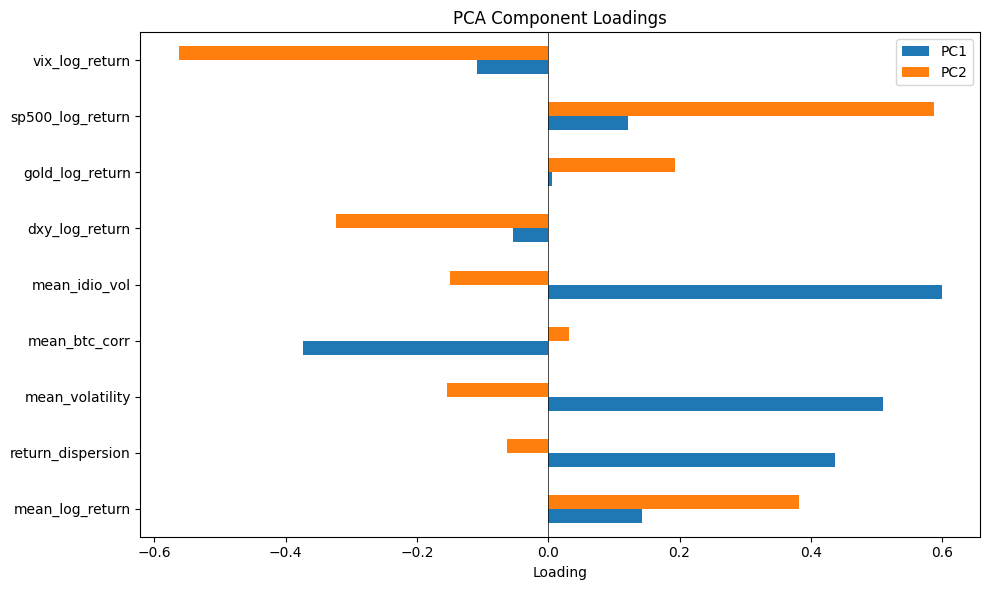

In [19]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_columns,
    columns=["PC1", "PC2"],
)

fig, ax = plt.subplots(figsize=(10, 6))
loadings.plot(kind="barh", ax=ax)
ax.set_title("PCA Component Loadings")
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Loading")

plt.tight_layout()
plt.show()

## Save outputs

The regime labels are saved alongside the daily market features so they can be used in downstream analysis and modeling.

In [20]:
output_df = daily_features_clean_df[["regime"]].copy()
output_df.to_csv(REGIME_LABELS_OUTPUT_PATH, index=True)

print(f"Saved regime labels to: {REGIME_LABELS_OUTPUT_PATH}")
print(f"Output shape: {output_df.shape}")

Saved regime labels to: C:\Users\taula\Github\HSLU\DSPRO2\HSLU_FS25_DSPRO2\data\processed\regime_labels_baseline.csv
Output shape: (2144, 1)


## Summary

This notebook clustered trading days into market regimes using K-Means on daily cross-sectional features.

**What was done:**
- Aggregated per-asset features into 9 daily market-state features (return statistics, volatility, BTC dependence, macro factors)
- Evaluated cluster counts from $k=2$ to $k=6$ using the elbow method and silhouette scores with each $k$ logging as a separate MLflow run
- Fit a final K-Means model with $k=2$ (matched to the HMM in notebook `06` for a fair comparison), characterized the resulting regimes, and logged the final run to MLflow (`clustering` experiment, `stage=final` tag)
- Analyzed cluster quality, PCA structure, and regime transition behavior

**Limitations:**
- Feature selection was fixed and not tuned